In [1]:
import numpy as np

In [2]:
x= np.linspace(-10,10,10)

In [3]:
y= 5+4*x-3*x**2+np.random.random(10)*100

In [4]:
from matplotlib import pyplot as plt

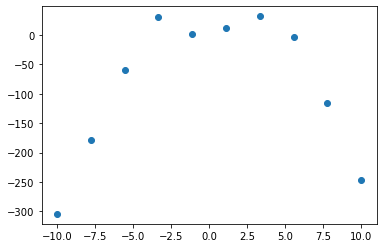

In [5]:
plt.scatter(x,y)

In [6]:
X=x.reshape(-1,1)

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [8]:
def compute_model_train_test_values(X,y,test_size=0.25):
    X_train,X_test,y_train,y_test=train_test_split(X,y,
                                                   test_size=test_size)
    model =LinearRegression()
    model.fit(X_train,y_train)
    y_pred_train=model.predict(X_train)
    rmse_train=mean_squared_error(y_train,y_pred_train)**0.5
    r2_train=model.score(X_train,y_train)
    
    y_pred_test=model.predict(X_test)
    rmse_test=mean_squared_error(y_test,y_pred_test)**0.5
    r2_test=model.score(X_test,y_test)
    return {
            "testing accuracy":r2_test,
            "training accuracy":r2_train,
            "rmse_test":rmse_test,
            "rmse_train":rmse_train,
            "intercept":model.intercept_,
            "coeff":model.coef_,
            "model":model
           }

In [9]:
result =compute_model_train_test_values(X,y)

In [10]:
result

{'testing accuracy': -0.9844023874601222,
 'training accuracy': 0.21009291929077079,
 'rmse_test': 167.0328932786297,
 'rmse_train': 96.75928467345214,
 'intercept': -56.077810666562485,
 'coeff': array([8.67928572]),
 'model': LinearRegression()}

In [11]:
y_pred=result["model"].predict(X)

In [12]:
y_pred

array([-142.87066785, -123.58336626, -104.29606466,  -85.00876306,
        -65.72146147,  -46.43415987,  -27.14685827,   -7.85955667,
         11.42774492,   30.71504652])

In [13]:
y

array([-304.18234057, -177.92996514,  -60.14278765,   30.60968692,
          1.60538761,   11.78222532,   31.63976263,   -4.33463878,
       -116.10046151, -247.29672068])

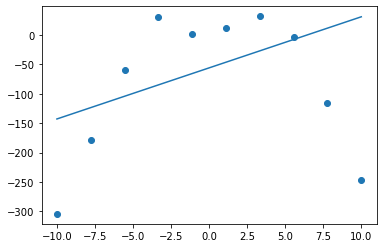

In [14]:
plt.scatter(x,y)
plt.plot(x,y_pred)

h(x)=a+bx+cx^2

X

In [15]:
X**2

array([[100.        ],
       [ 60.49382716],
       [ 30.86419753],
       [ 11.11111111],
       [  1.2345679 ],
       [  1.2345679 ],
       [ 11.11111111],
       [ 30.86419753],
       [ 60.49382716],
       [100.        ]])

In [16]:
X_mult=np.hstack([X,X**2])

In [17]:
X_mult.shape

(10, 2)

In [18]:
qaud_result=compute_model_train_test_values(X_mult,y)

In [19]:
y_pred_quad=qaud_result["model"].predict(X_mult)

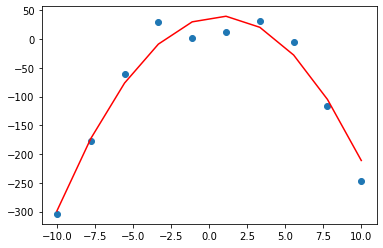

In [20]:
plt.scatter(x,y)
plt.plot(x,y_pred_quad,"r")

## Saving the mode

In [21]:
import pickle

In [22]:
with open("li_model.pickle","wb") as file:
    pickle.dump(qaud_result["model"],file)


## Feature Enginnering from sklearn(Poly fetaures)

In [23]:
from sklearn.preprocessing import PolynomialFeatures

In [24]:
poly_transformer=PolynomialFeatures()

In [25]:
poly_transformer.fit(X)

PolynomialFeatures()

In [26]:
poly_transformer.transform(X)[:4]

array([[  1.        , -10.        , 100.        ],
       [  1.        ,  -7.77777778,  60.49382716],
       [  1.        ,  -5.55555556,  30.86419753],
       [  1.        ,  -3.33333333,  11.11111111]])

In [27]:
X_mult[:4]

array([[-10.        , 100.        ],
       [ -7.77777778,  60.49382716],
       [ -5.55555556,  30.86419753],
       [ -3.33333333,  11.11111111]])

In [28]:
poly_transformer.fit_transform(X)

array([[  1.        , -10.        , 100.        ],
       [  1.        ,  -7.77777778,  60.49382716],
       [  1.        ,  -5.55555556,  30.86419753],
       [  1.        ,  -3.33333333,  11.11111111],
       [  1.        ,  -1.11111111,   1.2345679 ],
       [  1.        ,   1.11111111,   1.2345679 ],
       [  1.        ,   3.33333333,  11.11111111],
       [  1.        ,   5.55555556,  30.86419753],
       [  1.        ,   7.77777778,  60.49382716],
       [  1.        ,  10.        , 100.        ]])

In [29]:
# underfittig and overfitting
# baise and varince 
# bais-variance-trade-off
# regularization
# classifcation


In [61]:
def compute_poly_model_train_test_values(X,y,degree=2,test_size=0.25):
    poly_transformer=PolynomialFeatures(degree=degree)
#     print(X[:4])
    X=poly_transformer.fit_transform(X)
#     print(X[:4])
    X_train,X_test,y_train,y_test=train_test_split(X,y,
                                                   test_size=test_size,
                                                   
#                                                random_state=90,
                                                   shuffle=False
                                                  )
    model =LinearRegression()
    model.fit(X_train,y_train)
    y_pred_train=model.predict(X_train)
    rmse_train=mean_squared_error(y_train,y_pred_train)**0.5
    r2_train=model.score(X_train,y_train)
    
    y_pred_test=model.predict(X_test)
    rmse_test=mean_squared_error(y_test,y_pred_test)**0.5
    r2_test=model.score(X_test,y_test)
    return {
            "testing accuracy":r2_test,
            "training accuracy":r2_train,
            "rmse_test":rmse_test,
            "rmse_train":rmse_train,
            "intercept":model.intercept_,
            "coeff":model.coef_,
            "model":model,
            "X":X
           }

In [31]:
compute_poly_model_train_test_values(X,y)

{'testing accuracy': 0.622404495400117,
 'training accuracy': 0.9650342142021358,
 'rmse_test': 48.19818090267306,
 'rmse_train': 22.591486365759973,
 'intercept': 35.94256394747928,
 'coeff': array([ 0.        ,  6.12245585, -2.71964588]),
 'model': LinearRegression(),
 'X': array([[  1.        , -10.        , 100.        ],
        [  1.        ,  -7.77777778,  60.49382716],
        [  1.        ,  -5.55555556,  30.86419753],
        [  1.        ,  -3.33333333,  11.11111111],
        [  1.        ,  -1.11111111,   1.2345679 ],
        [  1.        ,   1.11111111,   1.2345679 ],
        [  1.        ,   3.33333333,  11.11111111],
        [  1.        ,   5.55555556,  30.86419753],
        [  1.        ,   7.77777778,  60.49382716],
        [  1.        ,  10.        , 100.        ]])}

In [32]:
compute_poly_model_train_test_values(X,y,degree=3)

{'testing accuracy': 0.9127684423545713,
 'training accuracy': 0.9717485345707909,
 'rmse_test': 27.32841842823001,
 'rmse_train': 20.480105176335584,
 'intercept': 53.42998176307415,
 'coeff': array([ 0.        ,  2.5437445 , -3.22872659,  0.00556859]),
 'model': LinearRegression(),
 'X': array([[    1.        ,   -10.        ,   100.        , -1000.        ],
        [    1.        ,    -7.77777778,    60.49382716,  -470.50754458],
        [    1.        ,    -5.55555556,    30.86419753,  -171.46776406],
        [    1.        ,    -3.33333333,    11.11111111,   -37.03703704],
        [    1.        ,    -1.11111111,     1.2345679 ,    -1.37174211],
        [    1.        ,     1.11111111,     1.2345679 ,     1.37174211],
        [    1.        ,     3.33333333,    11.11111111,    37.03703704],
        [    1.        ,     5.55555556,    30.86419753,   171.46776406],
        [    1.        ,     7.77777778,    60.49382716,   470.50754458],
        [    1.        ,    10.        ,   1

In [62]:
def compute_and_visualize(X,y,degree=2,test_size=0.25):
    result =compute_poly_model_train_test_values(X,y,degree=2,test_size=0.25)
    y_pred_quad=result["model"].predict(result["X"])
    del result["X"]
    print(result)
    plt.scatter(x,y)
    plt.plot(x,y_pred_quad,"r")
    

{'testing accuracy': 0.9244630007553364, 'training accuracy': 0.9654361416297914, 'rmse_test': 27.29010349585265, 'rmse_train': 22.08472687707042, 'intercept': 38.22800643592622, 'coeff': array([ 0.        ,  2.23552653, -3.15692543]), 'model': LinearRegression()}


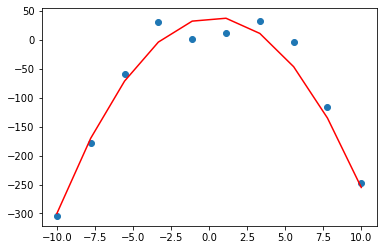

In [65]:
compute_and_visualize(X,y,degree=2)

{'testing accuracy': 0.954694509659817, 'training accuracy': 0.9550742701439124, 'rmse_test': 26.335370366370405, 'rmse_train': 21.870532930019213, 'intercept': 36.71398580410342, 'coeff': array([ 0.        ,  2.19813428, -3.0520948 ]), 'model': LinearRegression()}


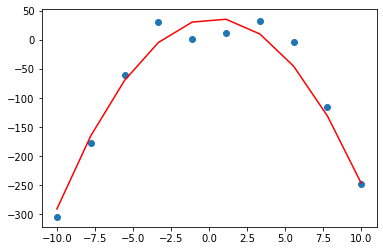

In [48]:
compute_and_visualize(X,y,degree=3)

{'testing accuracy': 0.9659478463346768, 'training accuracy': 0.889918768920961, 'rmse_test': 27.079965977464735, 'rmse_train': 23.701382681395412, 'intercept': 35.594047952517585, 'coeff': array([ 0.        ,  3.64143976, -2.80968499]), 'model': LinearRegression()}


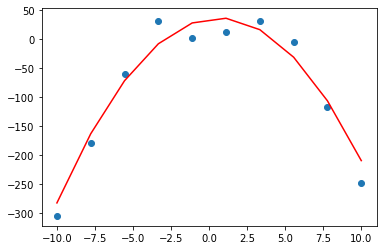

In [36]:
compute_and_visualize(X,y,degree=40)

{'testing accuracy': 0.6005213753449774, 'training accuracy': 0.9817884781162205, 'rmse_test': 71.74558133793148, 'rmse_train': 15.557061710665947, 'intercept': 26.176682846968987, 'coeff': array([ 0.        ,  7.21436929, -2.46219466]), 'model': LinearRegression()}


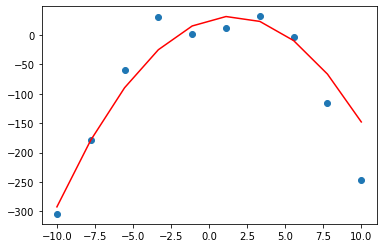

In [46]:
compute_and_visualize(X,y,degree=50)

In [ ]:
train_test_split()